In [1]:
# For users following this tutorial:
# !pip install ragpill langchain-huggingface sentence-transformers ipywidgets
# Or if you're developing locally with this repo:
# !uv sync --group docs

## Settings

Context: The settings are optional but an easy way to configure for standard use cases.
If you need more control over the client that is passed to [LLMJudge](../api/evaluators.md#llmjudge), you can also pass a pydantic-ai model directly.

To set up mlflow tracking and LLMJudge, you can create a `.env` file in the root of your project with the following content:

```env
# --- MLflow ---
# URI of your MLflow tracking server (default: http://localhost:5000)
MLFLOW_RAGPILL_TRACKING_URI=http://localhost:5000

# Name of the MLflow experiment (default: ragpill_experiment)
MLFLOW_RAGPILL_EXPERIMENT_NAME=my_experiment

# Human-readable description attached to each MLflow run (default: RAGPill Evaluation Run)
MLFLOW_RAGPILL_RUN_DESCRIPTION=My Evaluation Run

# Optional: credentials for a secured MLflow server
MLFLOW_TRACKING_USERNAME=your_username
MLFLOW_TRACKING_PASSWORD=your_password

# --- LLMJudge ---
# Model name passed to the LLM provider (default: gpt-4o)
RAGPILL_LLMJUDGE_MODEL_NAME=gpt-4o

# Sampling temperature for the judge model (default: 0.0)
RAGPILL_LLMJUDGE_TEMPERATURE=0.0

# Optional: base URL for a custom or self-hosted LLM API endpoint.
# Falls back to OPENAI_BASE_URL, then https://api.openai.com/v1
RAGPILL_LLMJUDGE_BASE_URL=https://your-llm-endpoint/v1

# Optional: API key for the LLM service.
# Falls back to OPENAI_API_KEY if not set.
RAGPILL_LLMJUDGE_API_KEY=sk-...
```

The cell below loads these settings and prints the resolved values so you can verify your configuration before running evaluations.

In [2]:
from ragpill.settings import MLFlowSettings, LLMJudgeSettings
from pprint import pprint
mlflow_settings = MLFlowSettings()
pprint(mlflow_settings)
llm_judge_settings = LLMJudgeSettings()
pprint(llm_judge_settings)

MLFlowSettings(ragpill_tracking_uri='http://127.0.0.1:5000', ragpill_experiment_name='ragpill_tutorial', tracking_username=None, tracking_password=None, ragpill_run_description='RAGPill Evaluation Run')
LLMJudgeSettings(model_name='openai/gpt-4o', temperature=0.0, base_url='https://openrouter.ai/api/v1', api_key=SecretStr('**********'))


## Defining the Testset



For more details on best practices for creating a testset, see the [Testsets](../guide/testsets.md ) guide.

Here we showcase the use of tags, attributes and "expected" attribute and how its propagated as default from Case to Evaluator.

In [3]:
from pydantic_evals import Dataset, Case
from ragpill import LLMJudge, TestCaseMetadata, RegexInOutputEvaluator
testset = Dataset(
    name="testset1",
    cases=[
        Case(
            inputs="What is the capital of France?",
            metadata=TestCaseMetadata(tags=["geography"], attributes={"author": "janine"}),
            evaluators=[
                LLMJudge(rubric="Paris is the capital of France"),
            ]
        ),
        Case(
            inputs="How many r`s are in 'strawberry'? State only the number",
            metadata=TestCaseMetadata(attributes={"author": "joel"}),
            evaluators=[
                RegexInOutputEvaluator(pattern="1", expected=False),
                RegexInOutputEvaluator(pattern="2", expected=False),
                RegexInOutputEvaluator(pattern="3", expected=True),
                RegexInOutputEvaluator(pattern="4", expected=False),
            ]
        )
    ]
)

## Creating the Task

In the end we just need a function (or if async: a coroutine) that takes in an inputs-`str` (usually a question from the user) and returns a `str` (usually the answer).
We will wrap a very simple [pydantic-ai Agent](https://ai.pydantic.dev/agent/)

In [4]:
from openai import AsyncOpenAI
import os
from httpx import AsyncClient

from pydantic_ai import Agent
from pydantic_ai.models.openai import OpenAIChatModel
from pydantic_ai.providers.openai import OpenAIProvider

api_key = os.environ["RAGPILL_LLMJUDGE_API_KEY"]
base_url = os.environ["RAGPILL_LLMJUDGE_BASE_URL"]
model_name = "qwen/qwen3.6-plus:free"
system_prompt = "You are a helpful assistant"
temperature = 0.2

http_client = AsyncClient()

openai_client = AsyncOpenAI(
    max_retries=3,
    base_url=base_url,
    api_key=api_key,
    http_client=http_client,
)
pyai_llm_model = OpenAIChatModel(
    model_name, provider=OpenAIProvider(openai_client=openai_client), settings={"temperature": temperature}
)

agent = Agent(model=pyai_llm_model, system_prompt=system_prompt)

## Running the Evaluation

In [5]:
import mlflow
from mlflow import MlflowClient

tracking_uri = mlflow_settings.ragpill_tracking_uri
try:
    client = MlflowClient(tracking_uri=tracking_uri)
    client.search_experiments()
    print(f"MLflow server reachable at {tracking_uri}")
except Exception:
    print(
        f"⚠️  MLflow server not reachable at {tracking_uri}.\n"
        "To track task runs start the server first:\n\n"
        "    mlflow server --backend-store-uri sqlite:///mlflow.db\n\n"
        "Then re-run this cell before continuing."
    )
    raise

MLflow server reachable at http://127.0.0.1:5000


In [6]:
async def task(question: str) -> str:
    result = await agent.run(question)
    return result.output

result = await task("Whats the capital of France?")
result

'The capital of France is Paris.'

In [7]:
from ragpill import evaluate_testset_with_mlflow
from IPython.display import display

async def task(question: str) -> str:
    result = await agent.run(question)
    return result.output


results_df = await evaluate_testset_with_mlflow(
    testset=testset,
    task=task,
    model_params={
        "system_prompt": system_prompt,
        "temperature": str(temperature),
        "model_name": model_name,
    }
)
display(results_df)

Output()

/Users/janine/ragpill/.venv/lib/python3.11/site-packages/pydantic_ai/models/openai.py:363: 
UserWarning: Sampling parameters ['temperature'] are not supported when reasoning is enabled. These settings will 
be ignored.
  warnings.warn(

🏃 View run shivering-eel-285 at: http://127.0.0.1:5000/#/experiments/1/runs/41a2f7621614499397858b8b710fd700
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


,inputs,output,evaluator_result,evaluator_data,evaluator_reason,expected,mandatory,attributes,tags,task_duration,evaluator_name,case_name,case_id,source_type,source_id,input_key,trace_id
0,How many r`s are in 'strawberry'? State only t...,3,True,{'evaluation_name': UUID('862e3b43-0816-4914-8...,"Regex pattern ""1"" did not match output.",False,True,"b'{""author"":""joel""}'",{},8.300706,RegexInOutputEvaluator,Case 2,186316f6b7363af58747eb755446be42,CODE,RegexInOutputEvaluator,186316f6b7363af58747eb755446be42,tr-31fbe3fa24195939e22b9cb3accd3309
1,How many r`s are in 'strawberry'? State only t...,3,True,{'evaluation_name': UUID('c3bffbad-f529-48bd-9...,"Regex pattern ""2"" did not match output.",False,True,"b'{""author"":""joel""}'",{},8.300706,RegexInOutputEvaluator_2,Case 2,186316f6b7363af58747eb755446be42,CODE,RegexInOutputEvaluator,186316f6b7363af58747eb755446be42,tr-31fbe3fa24195939e22b9cb3accd3309
2,How many r`s are in 'strawberry'? State only t...,3,True,{'evaluation_name': UUID('1841aa0b-c08b-4e22-8...,"Regex pattern ""3"" matched output.",True,True,"b'{""author"":""joel""}'",{},8.300706,RegexInOutputEvaluator_3,Case 2,186316f6b7363af58747eb755446be42,CODE,RegexInOutputEvaluator,186316f6b7363af58747eb755446be42,tr-31fbe3fa24195939e22b9cb3accd3309
3,How many r`s are in 'strawberry'? State only t...,3,True,{'evaluation_name': UUID('8dba0bf5-a737-405b-a...,"Regex pattern ""4"" did not match output.",False,True,"b'{""author"":""joel""}'",{},8.300706,RegexInOutputEvaluator_4,Case 2,186316f6b7363af58747eb755446be42,CODE,RegexInOutputEvaluator,186316f6b7363af58747eb755446be42,tr-31fbe3fa24195939e22b9cb3accd3309
4,What is the capital of France?,The capital of France is Paris.,True,Paris is the capital of France,The output correctly states that the capital o...,True,True,"b'{""author"":""janine""}'",{geography},6.488402,LLMJudge,Case 1,cb0b4aaf80c43c9973aefeda1bd72890,LLM_JUDGE,LLMJudge,cb0b4aaf80c43c9973aefeda1bd72890,tr-9c4a0bcdd2ea67283d2a3c1d2a23ab49


[Trace(trace_id=tr-9c4a0bcdd2ea67283d2a3c1d2a23ab49), Trace(trace_id=tr-631eec840df15383f265edcd1ad98bd9), Trace(trace_id=tr-31fbe3fa24195939e22b9cb3accd3309)]

## Mlflow Screenshots

In the UI, go to Evaluation Runs and click on the small Icon next to your experiment run to show it in a new window. There you will see the details of this experiment run, the most important data:

### Experiment Overview 

metrics per tag and the provided model_params:

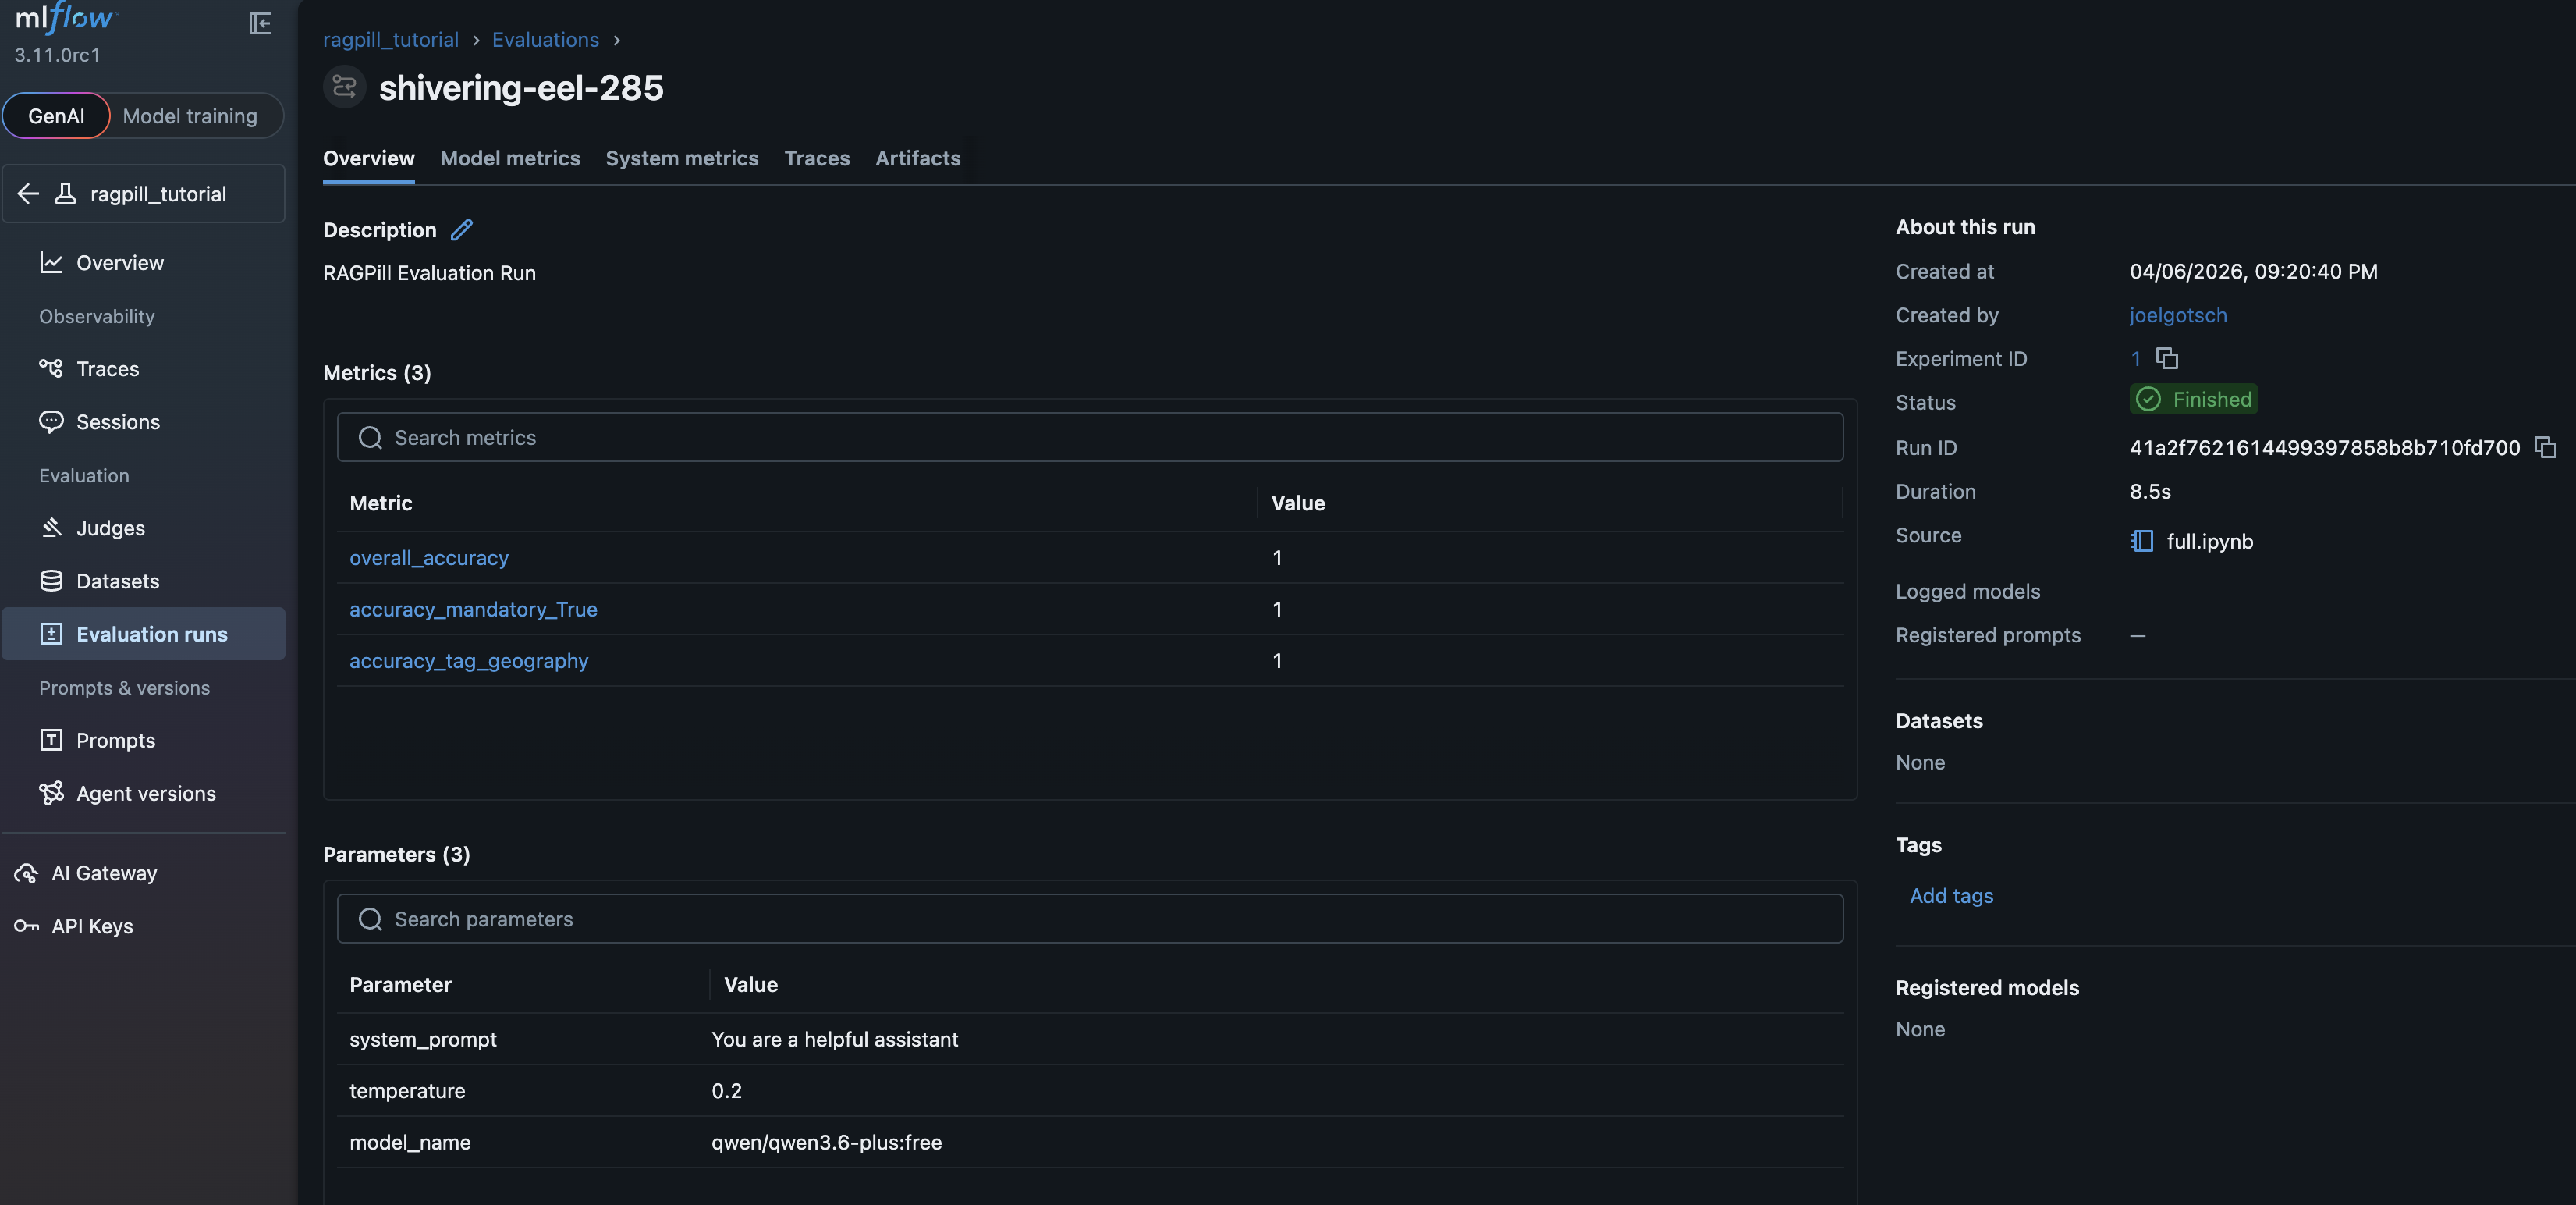

### Experiment Traces 

Assessments (=Evaluator Results) per Trace (=Case):


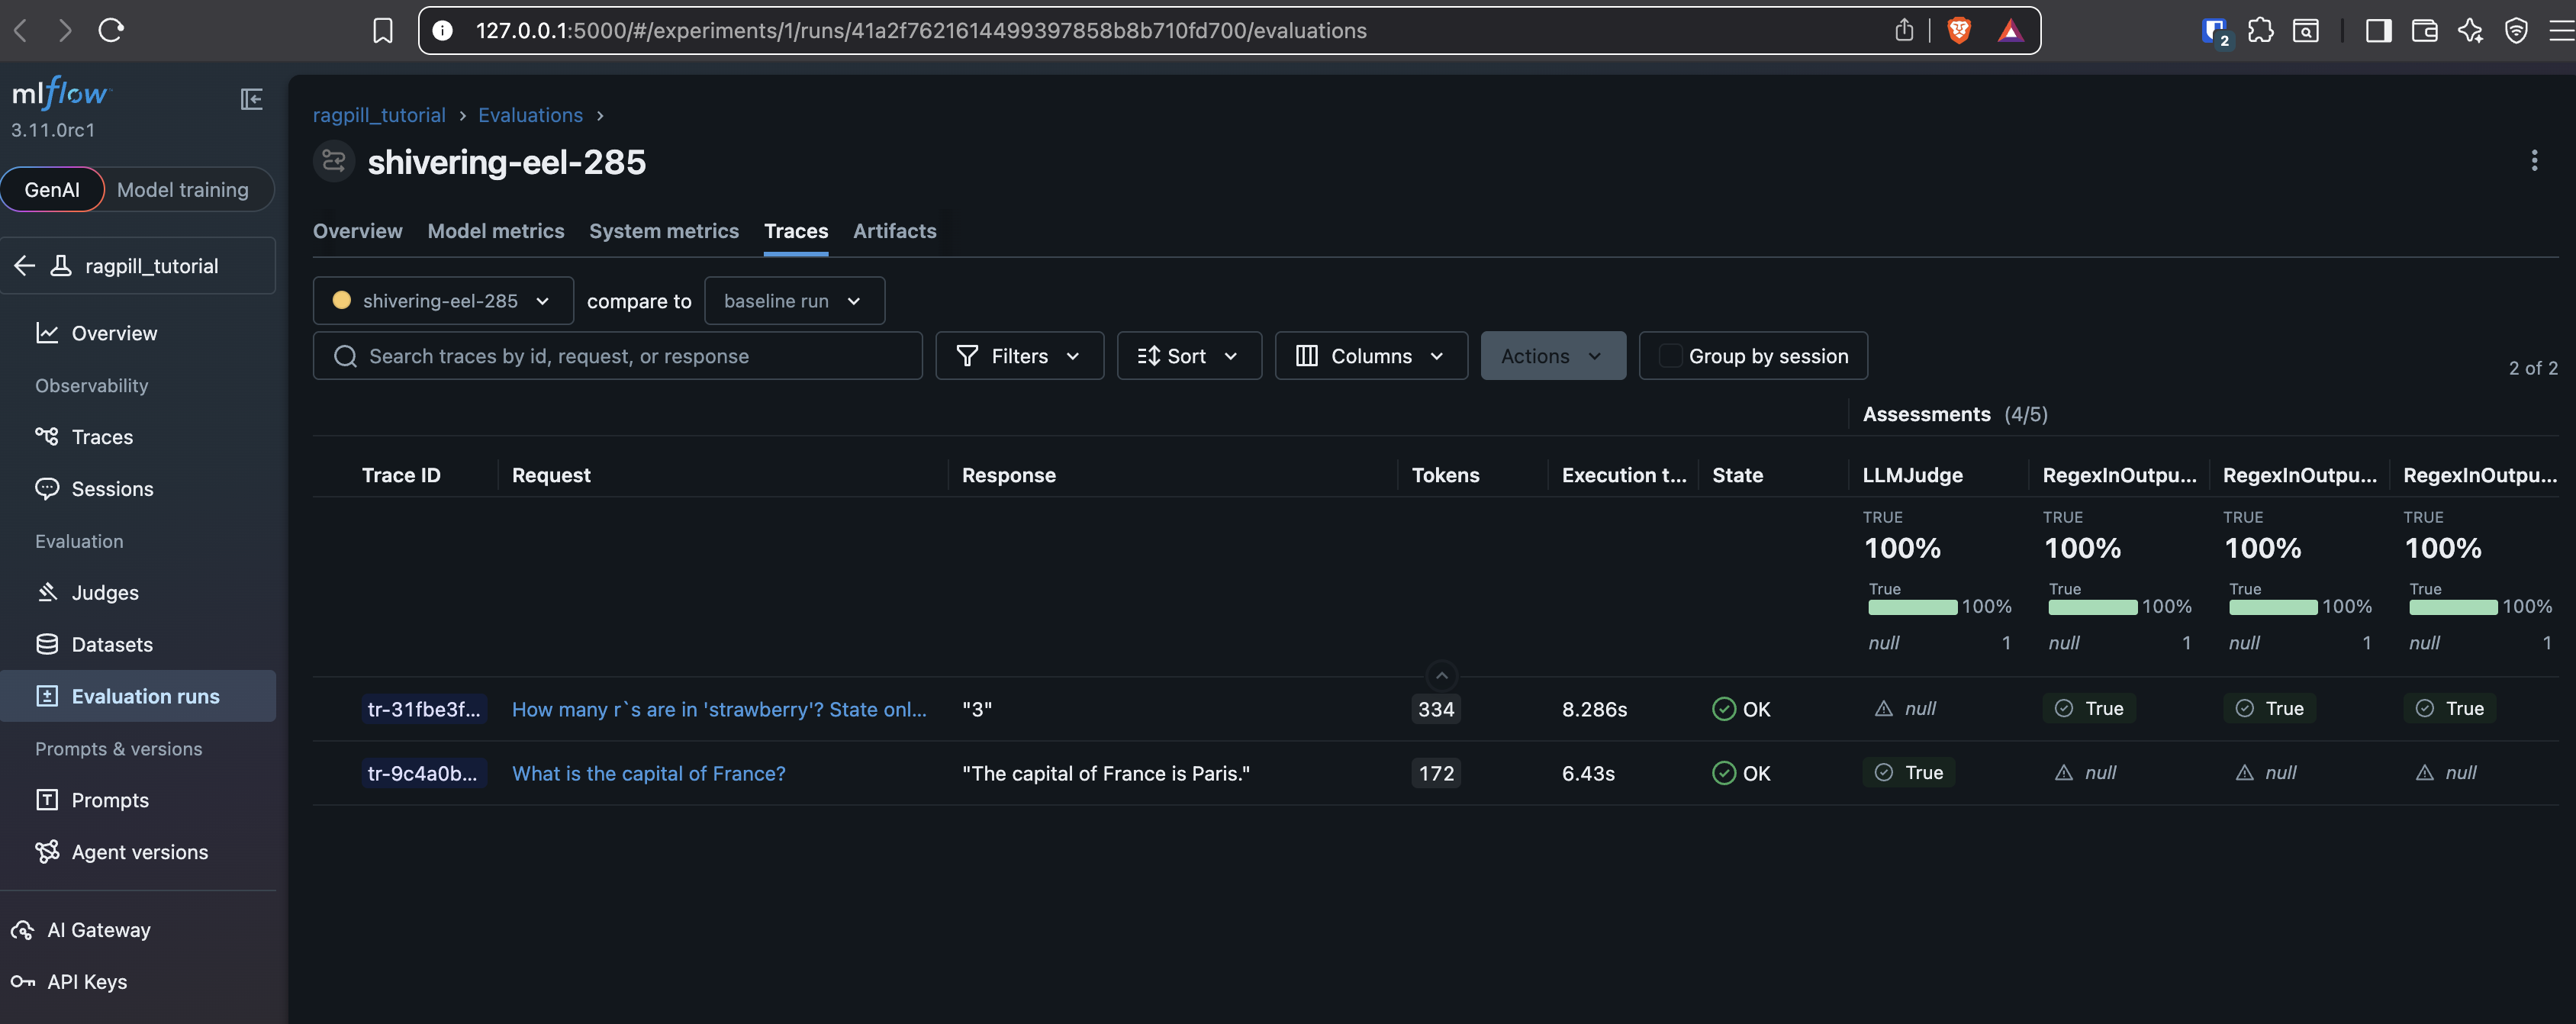


Note: Traces would usually also show the used tool calls and their results, like retrieved Documents if a Retriever was used etc. In this case we had a plain agent without tools.

### Experiment Artifacts 

The Dataframe thats also returned from evaluate_testset_with_mlflow

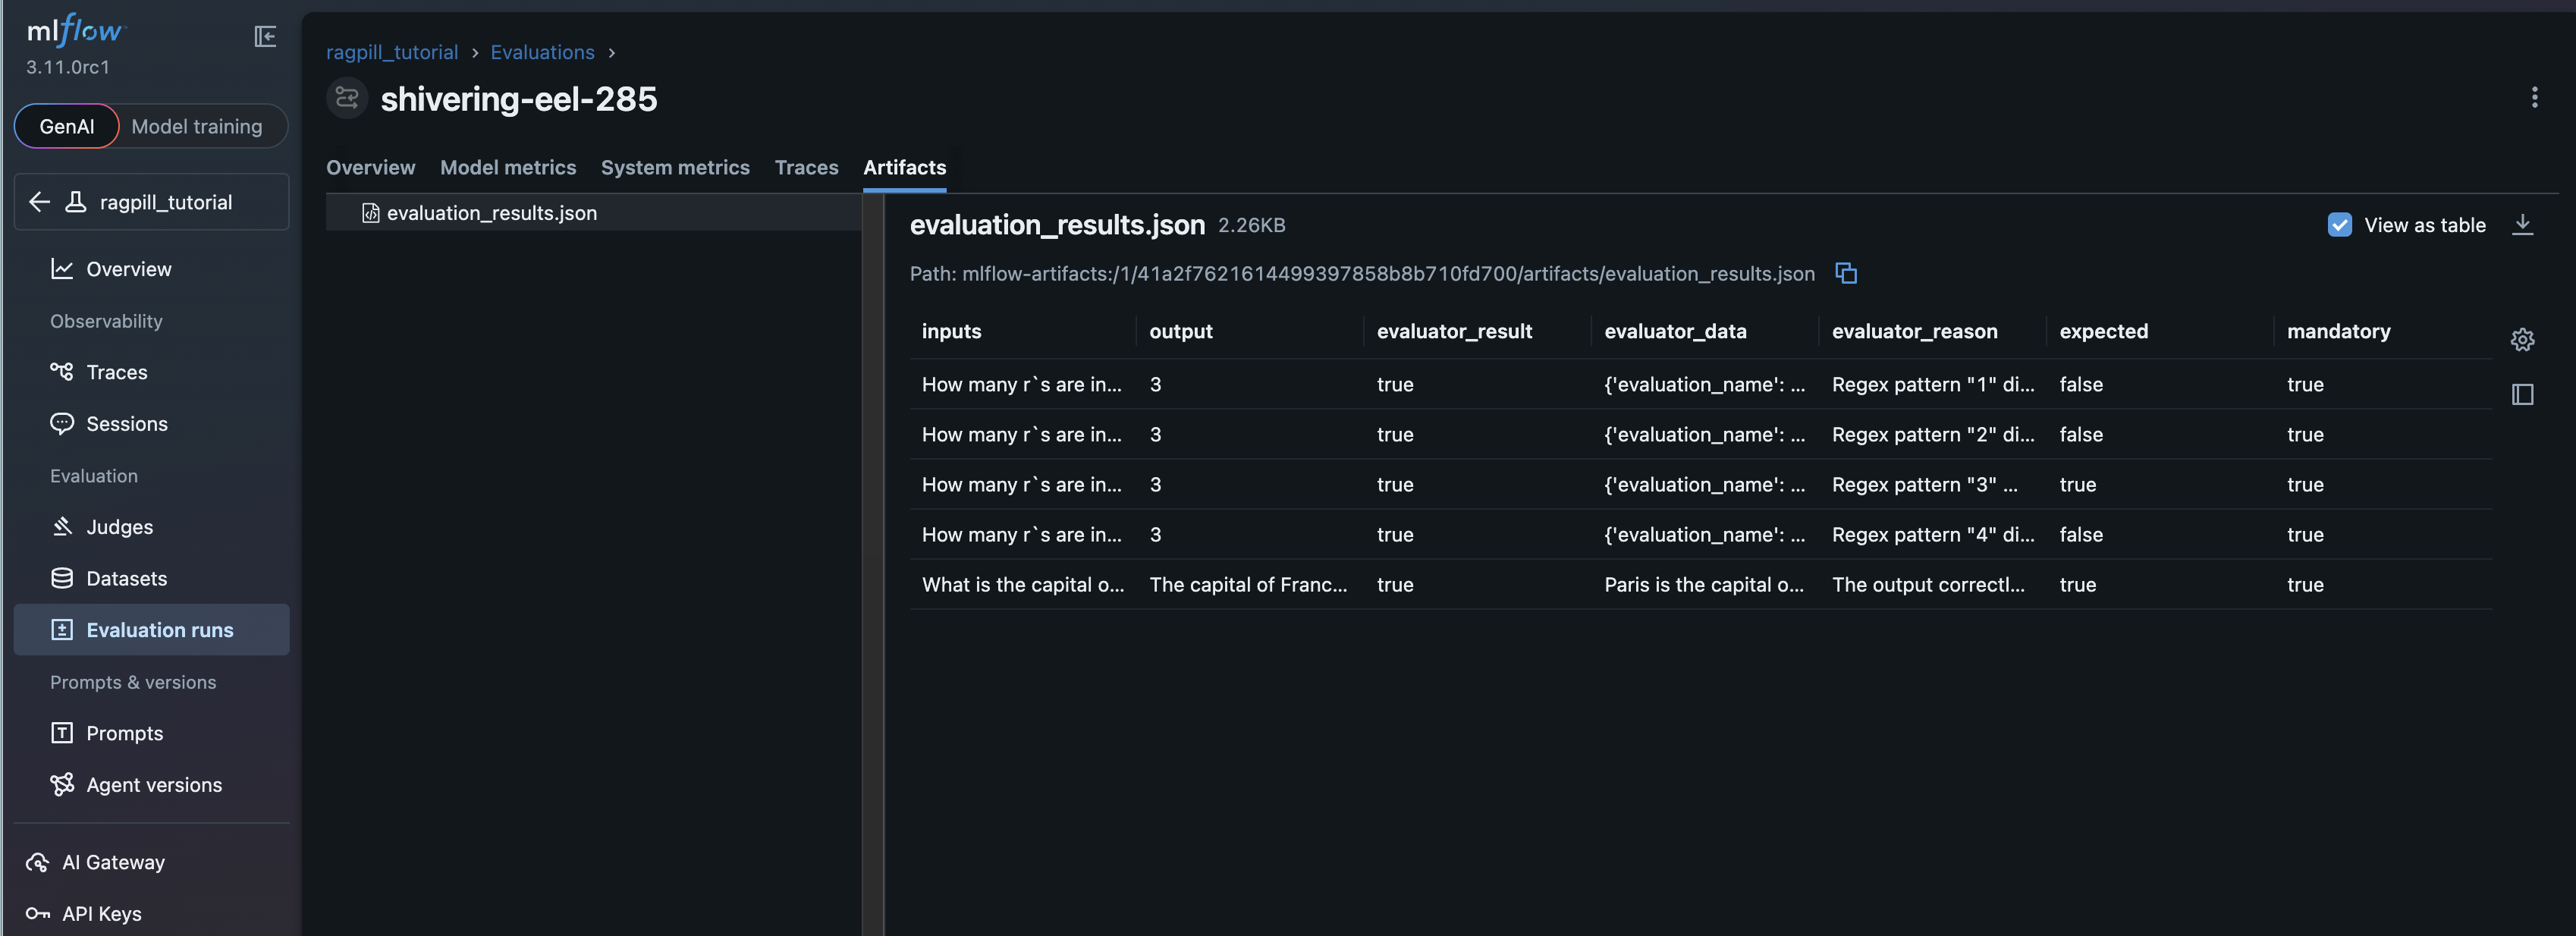